# 2. Flat Frame Analysis

### Why flat frames?
Flat fields (or “flats”) are images taken of a uniformly illuminated surface (e.g., the twilight sky or a screen inside the dome). They record the pixel‑to‑pixel sensitivity variations of the CCD and optical system, including:
- **Vignetting** – fall‑off in illumination toward the edges of the field.
- **Dust motes** – shadows from dust particles on the optical surfaces or the CCD window.
- **Quantum efficiency variations** – differences in how individual pixels convert photons to electrons.
- **Fringing** – interference patterns that can appear in narrow‑band filters.

By dividing the science images by a properly normalized master flat, we remove these systematic effects and obtain a frame where the response is uniform across the field.

## Objectives
1. Read all flat frames (provided as FITS files) and convert them to electrons using the known gain.
2. Subtract the **master bias** (created in the previous notebook) to remove the electronic offset.
3. Normalize each flat by its median value – this corrects for variations in the overall illumination level between individual flats.
4. Combine the normalized flats into a **master flat** by taking the median pixel‑by‑pixel (robust to cosmic rays and other outliers).
5. Inspect the master flat (image, row/column profiles) to verify its quality.
6. Save the master flat for later use in science frame reduction.

A well‑constructed master flat is essential for accurate photometry and astrometry, as it ensures that the final science images are free from additive and multiplicative instrumental signatures.


In [1]:
# -----Imports-----
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits # Astropy FITS handling
import pickle


# Plot style
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["EB Garamond", "Georgia", "Times New Roman"],
    # ---- Sizes ----
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.labelweight": "light",  # x/y labels
    "font.weight": "light",
    # ---- Axes/ticks style like the PDF ----
    "axes.edgecolor": "0.2",
    "axes.linewidth": 0.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.minor.width": 0.4,
    "ytick.minor.width": 0.4,

    "axes.grid": False,
    "axes.labelcolor": "0.2",
    "xtick.color": "0.2",
    "ytick.color": "0.2",
    "text.color": "0.2",
})


%matplotlib widget


In [2]:
# Read the list of flat frame filenames

flat_list = np.genfromtxt("./group15_WASP-12_20191229/flat/flat.list", dtype=str)
print(flat_list)


['AF580626.fits' 'AF580627.fits' 'AF580628.fits' 'AF580629.fits'
 'AF580630.fits' 'AF580631.fits' 'AF580632.fits' 'AF580633.fits'
 'AF580634.fits' 'AF580635.fits' 'AF580636.fits' 'AF580637.fits'
 'AF580638.fits' 'AF580639.fits' 'AF580640.fits' 'AF580641.fits'
 'AF580642.fits' 'AF580643.fits' 'AF580644.fits' 'AF580645.fits'
 'AF580646.fits' 'AF580647.fits' 'AF580648.fits' 'AF580649.fits'
 'AF580650.fits' 'AF580651.fits' 'AF580652.fits' 'AF580653.fits'
 'AF580654.fits' 'AF580655.fits']


In [3]:
# Load median bias file and set known parameters
median_bias = pickle.load(open("median_bias.p", "rb"))
bias_std = 1.31 # [e] photoelectrons
readout_noise = 7.10 # [e] photoelectrons
gain = 1.91 # [e/ADU]

## Inspect a single bias frame


In [4]:
# This cell opens the first flat and converts it to electrons. 
# We multiply by the gain because the raw FITS values are in ADU. 
# Converting early ensures all subsequent calculations are in consistent units.

flat00_fits = fits.open('./group15_WASP-12_20191229/flat/' + flat_list[0])
flat00_data = flat00_fits[0].data * gain

print('CCD Gain         : {0:4.2f} {1:.8s}'.format(flat00_fits[0].header['GAIN'],flat00_fits[0].header.comments['GAIN']))
print('CCD Readout noise: {0:4.2f} {1:.3s}'.format(flat00_fits[0].header['RDNOISE'],flat00_fits[0].header.comments['RDNOISE']))
print('Shape of the FITS image from the header : {0:4d} x {1:4d} pixels'.format(flat00_fits[0].header['NAXIS1'], flat00_fits[0].header['NAXIS2']))



CCD Gain         : 1.91 [e/ADU] 
CCD Readout noise: 7.10 [e]
Shape of the FITS image from the header :  521 x  222 pixels


## Displaying the first flat

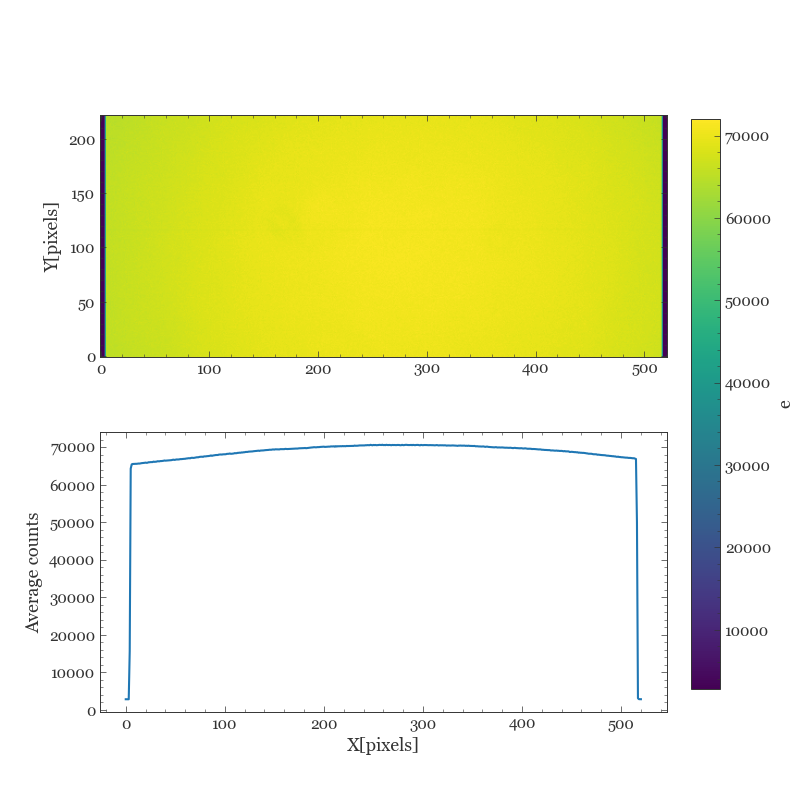

In [27]:
median_column = np.average(flat00_data, axis=0) 


fig, ax = plt.subplots(2,1, figsize=(8,8)) 


im1 = ax[0].imshow(flat00_data, origin='lower') 
im2= ax[1].plot(median_column)


cbar = fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('e')

ax[0].set_ylabel('Y[pixels]')

ax[1].set_xlabel('X[pixels]')
ax[1].set_ylabel('Average counts')


plt.show()

- The image (top) shows the overall illumination pattern: vignetting (darker edges), dust shadows (dark spots), and possibly fringing.
- The lower plot is the column‑averaged profile. It quantifies the large‑scale illumination trend and reveals any asymmetries that must be corrected by the flat field.

## Determining the data range and plotting with limits
Trimming the first and last 12 columns avoids edge pixels that are often saturated or poorly illuminated. The resulting vmin/vmax give a dynamic range that excludes the extreme values, making the image display more informative.
The subsequent plot then uses these limits to avoid extreme pixel values washing out the contrast.

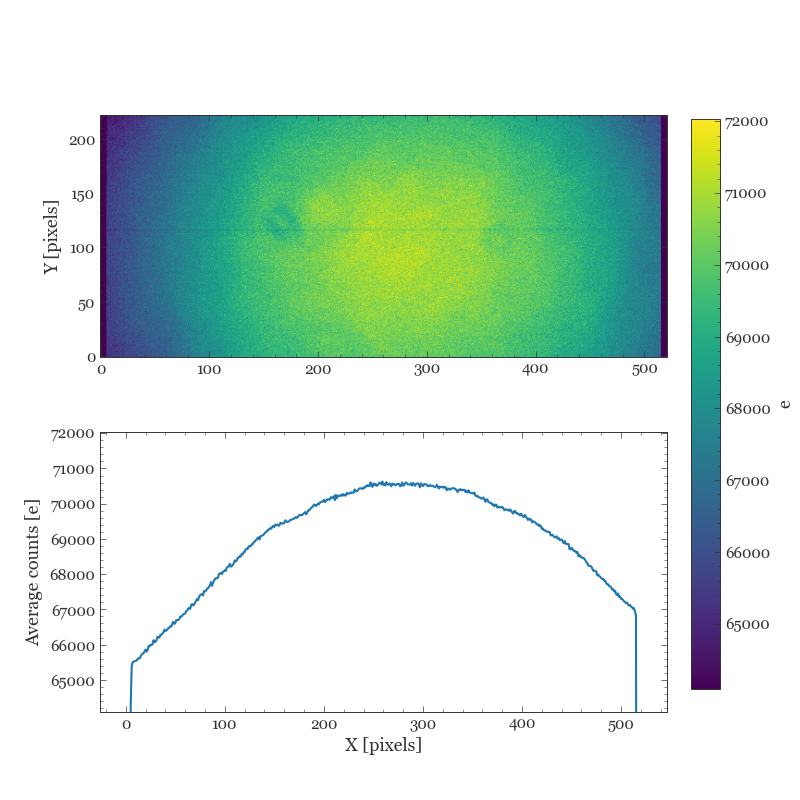

In [28]:
# Plotting the frame again with some changes

vmin = np.amin(flat00_data[:, 12:-12])
vmax = np.amax(flat00_data[:, 12:-12])

fig, ax = plt.subplots(2,1, figsize=(8,8)) 

im1 = ax[0].imshow(flat00_data, origin='lower', vmin=vmin, vmax=vmax) # added min an max
im2 = ax[1].plot(median_column)

# we set the plot limits 
ax[1].set_ylim(vmin,vmax)

cbar = fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("e")

ax[0].set_ylabel('Y [pixels]')

ax[1].set_xlabel('X [pixels]')
ax[1].set_ylabel('Average counts [e]')
plt.show()

## Building the flat stack
We store all bias‑subtracted flats in a 3‑D stack. This allows us to later compute median along the first axis to create a master flat that is robust against cosmic rays and transitory features.

In [9]:
n_images = len(flat_list)
flat00_nparray_dim00, flat00_nparray_dim01 = np.shape(flat00_data)


stack = np.empty([n_images, flat00_nparray_dim00, flat00_nparray_dim01])

for i_flat, flat_name in enumerate(flat_list):
    flat_temp = fits.open('./group15_WASP-12_20191229/flat/'+flat_name)
    stack[i_flat,:,:] = flat_temp[0].data * flat_temp[0].header['GAIN'] - median_bias
    flat_temp.close()

## Defining a window for normalisation
A central window (here 50×50 pixels) is chosen to compute the median illumination level of each flat. The centre of the field is typically the region least affected by vignetting and dust. Normalising each flat by its own central median compensates for any variations in the exposure level between different flat frames.

In [29]:
windows_size = 50
# x0, x1, y0, y1 represents the coordinates of the four corners
x0 = np.int16(flat00_nparray_dim01/2 - windows_size/2)
x1 = np.int16(flat00_nparray_dim01/2 + windows_size/2)
y0 = np.int16(flat00_nparray_dim00/2 - windows_size/2)
y1 = np.int16(flat00_nparray_dim00/2 + windows_size/2)

print('Coordinates of the box: x0:{0}, x1:{1}, y0:{2}, y1:{3}'.format(x0, x1, y0, y1))

Coordinates of the box: x0:235, x1:285, y0:86, y1:136


## Computing normalisation factors
For each flat, we take the median value inside the central window. This single number represents the “scale” of that flat. Later, we will divide every pixel of that flat by this factor, so that the central region becomes 1.0 in the normalised flat.

In [31]:
normalization_factors = np.median(stack[:,y0:y1, x0:x1], axis=(1,2))
print('Number of normalization factors (must be the same as the number of frames): {0}'.format(np.shape(normalization_factors)))
print(normalization_factors)


Number of normalization factors (must be the same as the number of frames): (30,)
[68196.55   68455.355  68250.03   68366.54   68187.955  68451.0575
 68229.02   68429.0925 68293.96   68442.4625 68285.8425 68463.4725
 68244.7775 68437.6875 68240.48   68450.58   68311.15   68443.895
 68294.915  68372.27   68269.6075 68486.87   68321.655  68464.4275
 68322.1325 68500.24   68280.59   68482.095  68287.275  68507.88  ]


## Estimating the uncertainty of the normalisation factors

The standard deviation of the pixel values inside the window, divided by the square root of the number of pixels, gives an estimate of the uncertainty in the median. This is useful for weighting later, and it also helps identify flats with unusually high noise (e.g., due to clouds).

In [32]:
normalization_factors_std = np.std(stack[:,y0:y1, x0:x1], axis=(1,2)) / np.sqrt(windows_size**2)
print(normalization_factors_std)

[6.49091374 6.30964692 6.60702319 6.56209055 6.22337822 6.55573255
 6.44091275 6.31735704 6.35890937 6.51668595 6.35521015 6.57674396
 6.43997908 6.36791648 6.52908989 6.51365307 6.47945835 6.46205774
 6.51784036 6.46543194 6.48377755 6.61794633 6.22881265 6.96689115
 6.40031612 6.45330486 6.48532881 6.37159746 6.57106562 6.34137309]


## Plotting the normalisation factors

The plot reveals if any flat frames have a drastically different illumination level – such frames might be rejected. The error bars show the precision of the median estimate; large error bars might indicate a noisy flat.

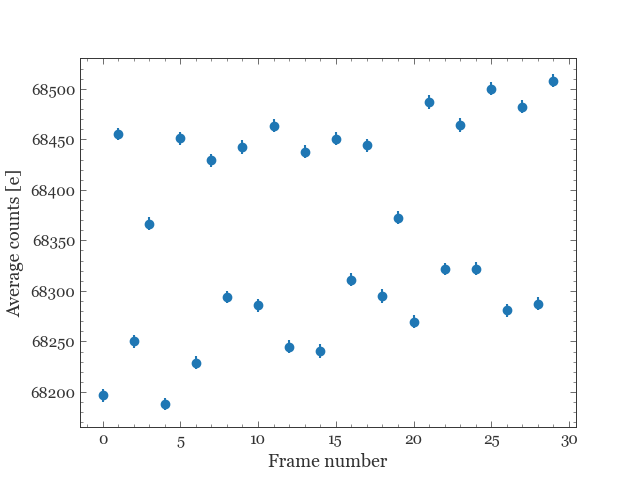

In [33]:
plt.figure()
x_frame = np.arange(0,n_images, 1)
plt.scatter(x_frame, normalization_factors)
plt.errorbar(x_frame, normalization_factors, normalization_factors_std, fmt='o', ms=2)
plt.xlabel('Frame number')
plt.ylabel('Average counts [e]')
plt.show()

## Normalising the stack
The division is performed using broadcasting after transposing so that each flat is divided by its own factor. This step produces a stack of normalised flats, each with a median of 1 in the central region.

In [34]:
stack_normalized_iter =  stack * 0. #initialization of the output array
for i_flat in range(n_images):
    stack_normalized_iter[i_flat,:,:] = stack[i_flat,:,:] / normalization_factors[i_flat]


In [35]:
print("shape of stack array           : ", np.shape(stack))
print("shape of transposed stack array: ", np.shape(stack.T))

stack_normalized = (stack.T / normalization_factors).T


print("shape of normalized stack array: ", np.shape(stack_normalized))

shape of stack array           :  (30, 222, 521)
shape of transposed stack array:  (521, 222, 30)
shape of normalized stack array:  (30, 222, 521)


## Creating the master flat
Taking the median pixel‑by‑pixel across all normalised flats produces the master flat. The median is preferred over the mean because it is resistant to outliers (e.g., cosmic ray hits that may appear in a single flat).

In [38]:
median_normalized_flat = np.median(stack_normalized, axis=0)

# Saving the results
pickle.dump(median_normalized_flat, open("median_normalized_flat.p", "wb")) 
pickle.dump(stack_normalized, open("flat_normalized_stack.p", "wb")) 
pickle.dump(normalization_factors, open("flat_normalization_factors.p", "wb")) 
pickle.dump(stack, open("flat_stack.p", "wb")) 

##  Final visualisation of the normalised flat


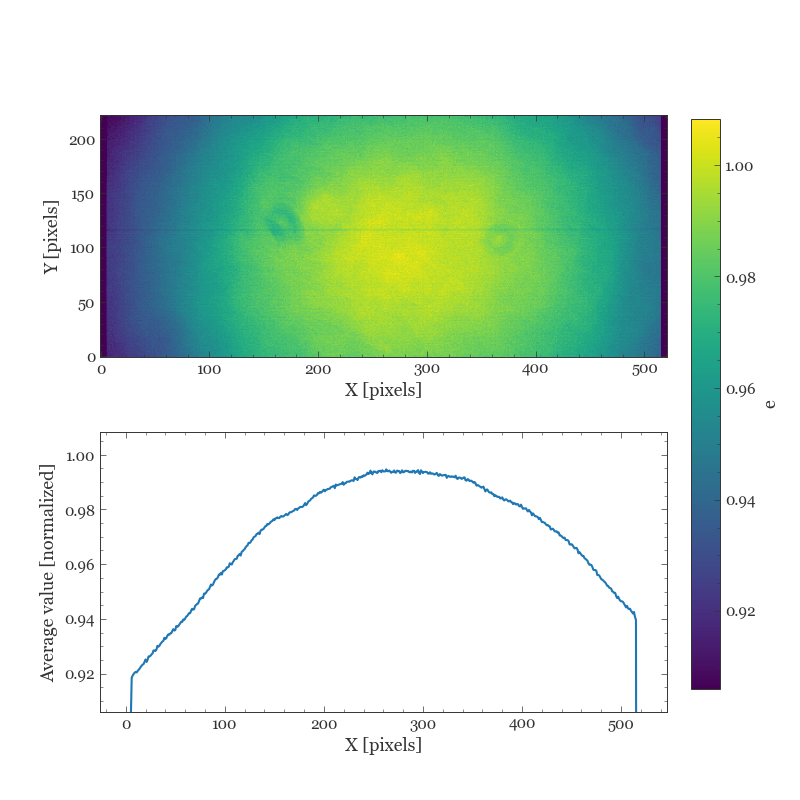

In [39]:
i_image = 0
nmin = np.amin(median_normalized_flat[:, 12:-12])
nmax = np.amax(median_normalized_flat[:, 12:-12])

median_column = np.average(median_normalized_flat, axis=0)

fig, ax = plt.subplots(2,1, figsize=(8, 8)) 

im1 = ax[0].imshow(median_normalized_flat, origin='lower', vmin=nmin, vmax=nmax)
im2 = ax[1].plot(median_column)

# we set the plot limits 
ax[1].set_ylim(nmin,nmax)

cbar = fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("e")

ax[0].set_xlabel('X [pixels]')
ax[0].set_ylabel('Y [pixels]')

ax[1].set_xlabel('X [pixels]')
ax[1].set_ylabel('Average value [normalized]')
plt.show()

In [40]:
photon_noise = np.sqrt(np.abs(stack))
stack_error = np.sqrt(readout_noise **2 + bias_std**2 +  photon_noise**2)
stack_normalized_error = (stack_error.T/normalization_factors).T 
median_normalized_flat_errors = np.sum(stack_normalized_error**2, axis=0) / n_images

pickle.dump(median_normalized_flat_errors, open("median_normalized_flat_errors.p", "wb")) 